# Lead Compensator Tutorial

- Prof. Hernán Felipe García Arias, PhD

- Faculty of Engineering - UdeA

- Control Systems

- 2026

# Problem

Consider the following open-loop system:

$$
L(s) = \frac{10}{s(s + 1)}
$$

Design the lead compensator such that the phase margin of the compensated system is at least $50^\circ$.

---

## Summary of the Design Procedure for the Phase Lead Compensator

**Design specification and goal:** Achieve a phase margin (PM) of the compensated system that is greater than or equal to the minimum desired value of $50^\circ$. Design the compensator parameters $a$ and $T$ in

$$
G_c(s) = \frac{1 + a\,T\,s}{1 + T\,s}, \qquad a > 1.
$$

The Bode plot of the phase lead compensator is shown in the figure below.

<img src = "https://aleksandarhaber.com/wp-content/uploads/2023/01/lead_compensation_modified-3-768x741.png">

## Procedure 1

**Step 1:**  
Plot the Bode plot of the uncompensated system and read its phase margin (PM). Compute the required additional phase, $\phi_{m}$, as the difference between the minimum desired PM (e.g. 50°) and the PM of the uncompensated system. Optionally, include a few extra degrees of safety.

**Step 2:**  
Determine the compensator gain ratio $a$ using  
$$
a = \frac{1 + \sin(\phi_{m})}{1 - \sin(\phi_{m})}.
$$

**Step 3:**  
Select $\omega_{m}$ (the frequency at which the compensator produces its maximum phase $\phi_{m}$) as the frequency where the magnitude of the uncompensated loop equals $-10\log_{10}(a)$. This choice ensures the closed-loop crossover occurs near $\omega_{m}$.

**Step 4:**  
Compute the time constant $T$ as  
$$
T = \frac{1}{\omega_{m}\sqrt{a}}.
$$

**Step 5:**  
Re-plot the Bode diagram of the compensated system and verify the specifications. If the phase margin is still below the target, increase $\phi_{m}$ and repeat Steps 2–5.


## Solution

Here, we present the solution of the problem. The MATLAB codes are given after each graph.

### Step 1
The Bode plot of the open-loop system is given below.


In [1]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 13.3 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import control

In [3]:
import control as ct

L = ct.tf([10],[1 ,1 ,0])
print('Open Loop TF: ', L)

# Generate Bode plot with margins
mag, phase, omega = control.bode(L, dB=True, plot=False)

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(L)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display



Open Loop TF:  <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    10
  -------
  s^2 + s


/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


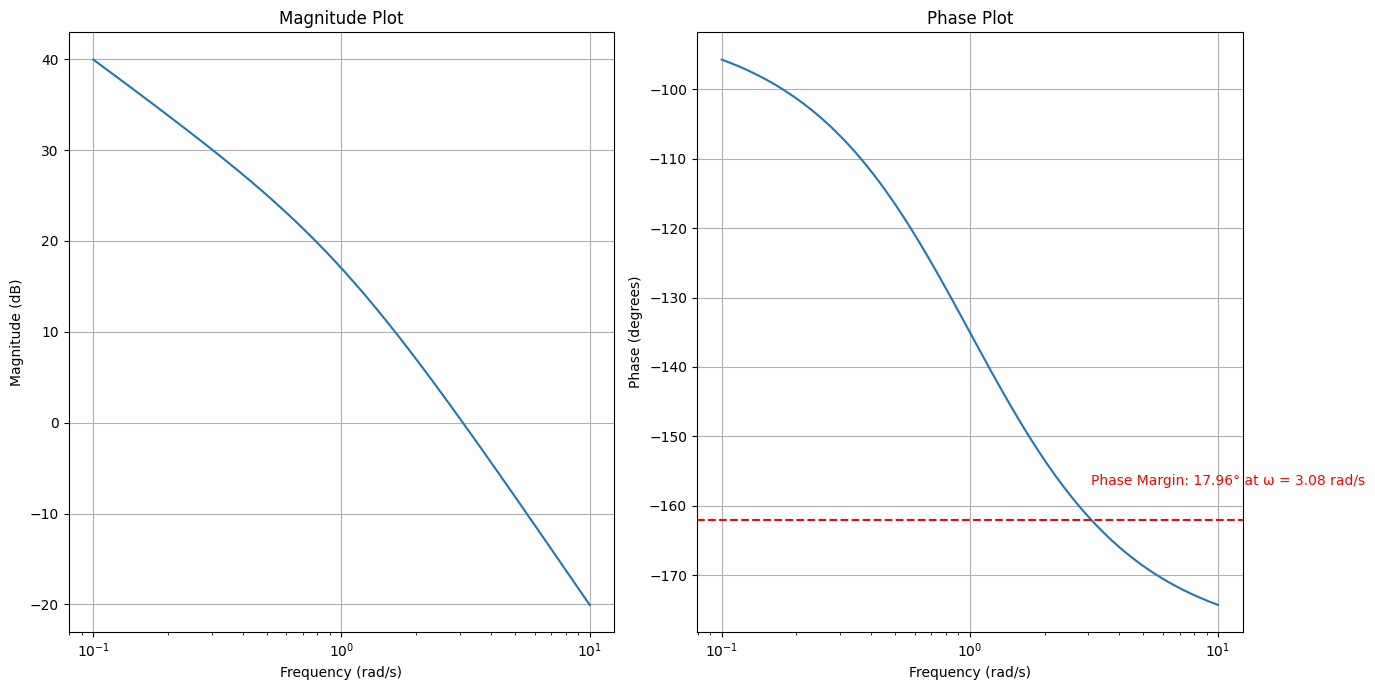

Phase Margin: 17.96° at ω = 3.08 rad/s


In [4]:
# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

We can observe that the phase margin of the open-loop uncompensated system is $18^\circ$ at the gain-crossover frequency of $3.08\ \mathrm{rad/s}$. Consequently, since the desired phase margin of the compensated system is $0^\circ$, the maximum phase advance required from the lead compensator is

$$
\phi_m = 50^\circ - 18^\circ + 5^\circ= 37^\circ.
$$

It is also instructive to plot the step response of the closed-loop system without the compensator. The step response is shown below.


In [5]:
phi_m = 50 - pm_deg + 5
print(phi_m)

37.035764083628635


Here, it is also instructive to plot the step response of the closed-loop system without the compensator. The step response of the closed-loop system is given below.

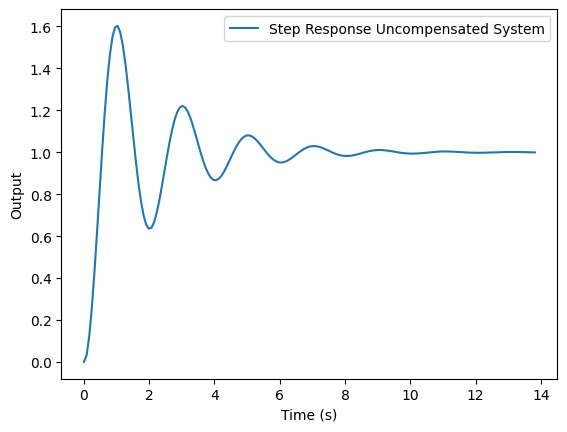

In [6]:
T, y = ct.step_response(ct.feedback(L,1))

plt.figure
plt.plot(T,y,label = 'Step Response Uncompensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

From  above figure, we can observe that the main issue with the step response of the closed loop of the uncompensated system is the large damping ratio. By increasing the phase margin, we will decrease the damping without affecting the steady-state characteristics.

## Step 2: Compute the Compensator Magnitude Ratio $a$

The parameter $a$ is given by
$$
a = \frac{1 + \sin(\phi_m)}{1 - \sin(\phi_m)}.
$$
First, convert $\phi_m = 32^\circ$ to radians:
$$
\phi_m = 32^\circ \times \frac{\pi}{180} = 0.5585\ \text{rad}.
$$
Substituting into the formula yields:
$$
a = \frac{1 + \sin(0.5585)}{1 - \sin(0.5585)} \approx 3.2546.
$$


In [7]:
phiM=50 - pm_deg + 5
phiMr=phiM*np.pi/180
a= (1+np.sin(phiMr))/(1-np.sin(phiMr))
print(a)

4.029085906587342


### Step 3: Determine the Compensator Corner Frequency $\omega_m$

We first compute the required gain attenuation in dB:
$$
-10\log_{10}(a) = -10\log_{10}(3.2546) \approx -5.1250\ \text{dB}.
$$
From the Bode plot of the uncompensated system, find the frequency $\omega_m$ at which the magnitude is $-5.1250$ dB.  
$$
\omega_m \approx 4.15\ \mathrm{rad/s}.
$$

---

### Step 4: Compute the Time Constant $T$

Once $\omega_m$ is known, select $T$ as:
$$
T = \frac{1}{\omega_m \sqrt{a}}
  = \frac{1}{4.15 \,\sqrt{3.2546}}
  \approx 0.1336\ \mathrm{s}.
$$


In [8]:
gain_att = -10*np.log10(a)
print(gain_att)

-6.052065273434778


In [10]:
# suppose mag, phase, omega are 1D numpy arrays,
# and mag is in dB (or whatever units your target is in)
mag = 20*np.log10(mag)
target = gain_att

# 1) nearest-neighbor
i = np.argmin(np.abs(mag - target))
omega_m_nearest = omega[i]
print(f"Nearest ωₘ ≃ {omega_m_nearest:.3f} rad/s")



Nearest ωₘ ≃ 3.087 rad/s


/tmp/ipykernel_13488/2550408986.py:3: RuntimeWarning: invalid value encountered in log10
  mag = 20*np.log10(mag)


In [11]:
T = 1/(omega_m_nearest*np.sqrt(a))
print(f"T ≈ {T:.4f} s")

T ≈ 0.1614 s


**STEP 5:** The Bode plot of the compensated system in the first iteration is given below

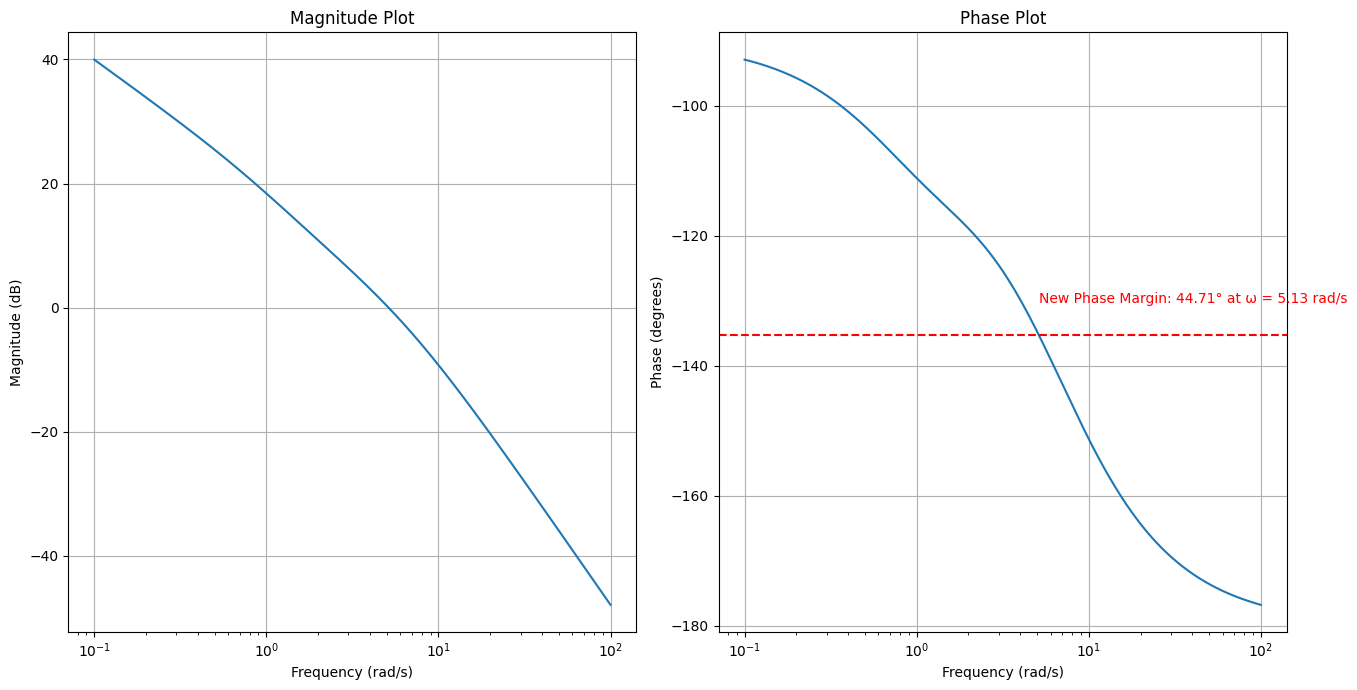

New Phase Margin: 44.71° at ω = 5.13 rad/s


In [13]:
Gc=ct.tf([a*T, 1],[T, 1])
Wcomp=Gc*L

# Generate Bode plot with margins
mag, phase, omega = control.bode(Wcomp, dB=True, plot=False)

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(Wcomp)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'New Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"New Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

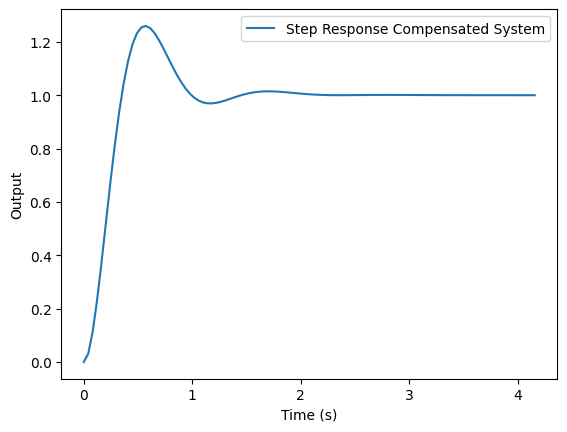

In [14]:
T, y = ct.step_response(ct.feedback(Wcomp,1))

plt.figure
plt.plot(T,y,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

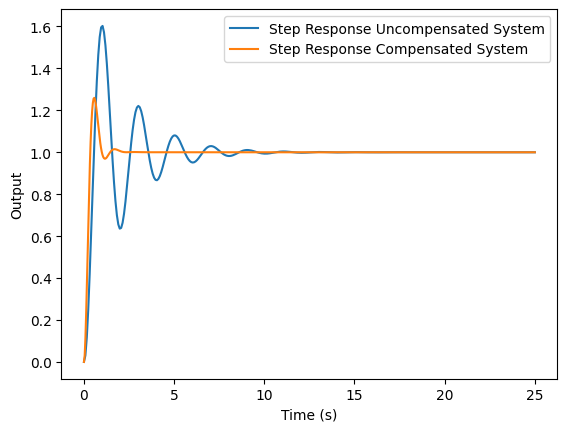

In [15]:


Wcomp=Gc*L

T1, y = ct.step_response(ct.feedback(L,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()